# CELL 1: Setup & Dependencies

In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
# Install packages
!pip install -q transformers[sentencepiece] fastbook fastai nbdev plum-dispatch evaluate seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.4/71.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 42.9 MB/s eta 0:00:00


In [ ]:
# Clone and navigate into blurr
!git clone https://github.com/msi1427/blurr.git
%cd blurr

Cloning into 'blurr'...
remote: Enumerating objects: 5063, done.
remote: Counting objects: 100% (890/890), done.
remote: Compressing objects: 100% (310/310), done.
remote: Total 5063 (delta 701), reused 699 (delta 573), pack-reused 4173 (from 1)
Receiving objects: 100% (5063/5063), 27.00 MiB | 26.30 MiB/s, done.
Resolving deltas: 100% (3932/3932), done.
/content/blurr


In [ ]:
#import pandas as pd

In [ ]:
# Core imports
import os
import torch
import json
import ast
import pandas as pd
from transformers import (
           AutoModelForSequenceClassification,
           AutoConfig
           #DistilBertTokenizer,
           #DistilBertForSequenceClassification)
)
from fastai.text.all import *
from blurr.text.data.all import *
from blurr.text.modeling.all import *

In [ ]:
# Mount Drive and target correct folder
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = '/content/drive/MyDrive/Startups_Recognize/NLP_Preprocessed_Dataset.csv'
df = pd.read_csv(DATA_PATH)

In [ ]:
%cd "/content/drive/MyDrive/Startups_Recognize"

/content/drive/MyDrive/Startups_Recognize


In [ ]:
#df = pd.read_csv("NLP_Preprocessed_Dataset.csv")

In [ ]:
df.head()

,name,motto,description,topics,url,topic_category
0,Flux Plugins,"Speed up WordPress with AI-powered image, SEO, and accessibility tools","Flux Plugins provides a suite of WordPress plugins that boost speed, accessibility, and SEO. The Flux Suite includes Media Optimizer for compressing and serving images efficiently and AI Alt Text & Accessibility Audit to generate alt text and flag issues affecting compliance. Install in minutes, reduce bandwidth, and keep visitors engaged with faster, more accessible pages.","['Blogging Platforms', 'Performance Marketing', 'SEO']",https://betalist.com/startups/flux-plugins,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
1,Wafaa.io BOOSTED,Create digital contracts in minutes,"Wafaa is your new one-stop shop for digital contracts. Create, sign, and send contracts in minutes so you can get back to work. Replace scattered and unsecured agreements across platforms and manage the full contract lifecycle at a glance. Protect your money and time with built-in fraud prevention, and skip the subscriptions by paying as you go. Try before you buy: your first contract is on us.","['SaaS', 'B2B', 'Freelancers']",https://betalist.com/startups/wafaa-io,"[0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
2,Vaulternal,Store and automate file access with secure file storage,"Vaulternal offers encrypted, decentralized file storage with zero-knowledge privacy and smart triggers. Files are encrypted client-side and stored across multiple decentralized blockchains, including Polygon, removing single points of failure and preventing provider access. You can set time-based, inactivity, manual, or blockchain-event conditions to deliver files to chosen recipients, enabling controlled sharing and inheritance. Sign up with email or connect a wallet, manage multiple recipients, and rely on verifiable permanence and client-side decryption.","['Lifestyle', 'SaaS']",https://betalist.com/startups/vaulternal,"[0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
3,PUBVOICE,Turn your articles into audio and boost reader engagement,"PUBVOICE converts your articles into high-quality audio and delivers it through an embeddable player. Connect your RSS feed to auto-detect new posts, let AI generate listener-friendly scripts, and choose from 30 adjustable voices. Control creation, delivery, and performance from a single dashboard with metrics like plays, dwell time, and completion rate. Customize the player with CSS, clone voices, and keep content private from AI training. Implementation takes minutes with a lightweight script tag, and early access grants all features for free.",['Analytics'],https://betalist.com/startups/pubvoice,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
4,OPT-IMG,"AI tool to optimize images for SEO, speed, and scale automatically","OPT-IMG is an AI-powered image SEO platform that turns r

In [ ]:
df.shape

(21353, 6)

In [ ]:
df.isnull().sum()

,0
name,0
motto,0
description,0
topics,0
url,0
topic_category,0


In [ ]:
df['topic_category'] = df['topic_category'].apply(ast.literal_eval)

# Encoding Data

In [ ]:
print(df.topics[0])

['Blogging Platforms', 'Performance Marketing', 'SEO']


In [ ]:
type(df.topics[0])

str

In [ ]:
list_category = df.topics.to_list()
encode_count = {}

for topics in list_category:
  topics = topics.replace("[", "").replace("'", "").replace("]", "")
  topics_list = topics.split(",")
  for topic in topics_list:
    topic = topic.strip()
    if topic in encode_count.keys():
      encode_count[topic] += 1
    else:
      encode_count[topic] = 1

In [ ]:
#print(encode_count)

In [ ]:
encode_topic_types = {key: idx for idx, (key, value) in enumerate(encode_count.items())}

In [ ]:
#encode_topic_types

# CELL 3: FastAI Dataloaders and Model Initialization

In [ ]:
labels = list(encode_topic_types.keys())

In [ ]:
#labels

In [ ]:
# Define Hugging Face variables
model_name = "roberta-base"
model_cls = AutoModelForSequenceClassification
config = AutoConfig.from_pretrained(model_name)
config.num_labels = len(labels)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

In [ ]:
hf_arch, hf_config, hf_tokenizer, hf_model = get_hf_objects(model_name, model_cls=model_cls, config=config, model_kwargs={'ignore_mismatched_sizes':True})
hf_model.config.problem_type = "multi_label_classification"

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

In [ ]:
# Build DataBlock
blocks = (TextBlock(hf_arch, hf_config, hf_tokenizer, hf_model), MultiCategoryBlock(encoded=True, vocab=labels))
dblock = DataBlock(blocks=blocks,
                   get_x=ColReader('description'),
                   get_y=ColReader('topic_category'),
                   splitter=RandomSplitter(valid_pct=0.1, seed=42))

In [ ]:
dls = dblock.dataloaders(df, bs=32)

In [ ]:
os.makedirs("dataloaders", exist_ok=True)
torch.save(dls, "dataloaders/dls-multilabel-roberta-base-book-classifier.pkl")

In [ ]:
# Generate Blurr Learner
model = BaseModelWrapper(hf_model)
acc_02 = partial(accuracy_multi, thresh=0.2)

metrics = [
    acc_02,
    PrecisionMulti(thresh=0.2),
    RecallMulti(thresh=0.2),
    F1ScoreMulti(thresh=0.2)
]

In [ ]:
learner = Learner(dls,
                  model,
                  opt_func=partial(OptimWrapper, opt=torch.optim.AdamW),
                  loss_func=BCEWithLogitsLossFlat(),
                  metrics=metrics,
                  cbs=[BaseModelCallback],
                  splitter=blurr_splitter
                  ).to_fp16()

# CELL 4: Stage 0 Training (Frozen Feature Layer)

In [ ]:
learner.freeze()

<div></div>

SuggestedLRs(slide=0.0008317637839354575, valley=0.0002290867705596611)

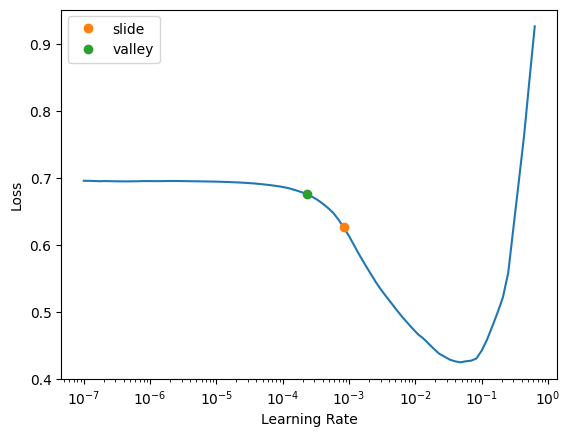

In [ ]:
# Find optimal starting learning rate
learner.lr_find(suggest_funcs=[slide, valley])

In [ ]:
# Fit top layers
learner.fit_one_cycle(2, slice(0.0008, 0.00023))

epoch,train_loss,valid_loss,accuracy_multi,precision_score,recall_score,f1_score,time
0,0.105110,0.099290,0.959352,0.065263,0.071616,0.055956,01:10
1,0.095389,0.092534,0.959018,0.111546,0.114155,0.099726,00:48


In [ ]:
# Create model directory and export intermediate states
os.makedirs("models-roberta-base", exist_ok=True)
learner.save("book-roberta-base-classifier-stage-0")
learner.export("models-roberta-base/book-roberta-base-classifier-stage-0.pkl")

# CELL 5: Stage 1 Training (Unfrozen Network Fine-Tuning)

In [ ]:
learner.unfreeze()

<div></div>

SuggestedLRs(slide=0.0008317637839354575, valley=3.311311274956097e-06)

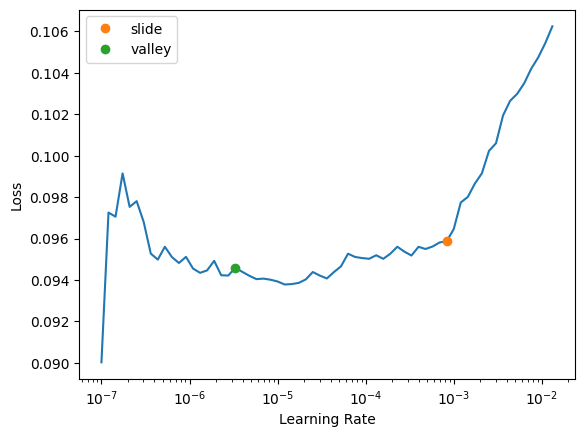

In [ ]:
# Find fine-tuning learning rate bounds
learner.lr_find(suggest_funcs=[slide, valley])

In [ ]:
# Fine-tune completely
learner.fit_one_cycle(10, slice(0.00083, 3.31e-6))

epoch,train_loss,valid_loss,accuracy_multi,precision_score,recall_score,f1_score,time
0,0.065429,0.071155,0.970289,0.369006,0.263078,0.266101,01:27
1,0.065296,0.071397,0.970707,0.389339,0.265517,0.273435,01:25
2,0.060775,0.068072,0.972606,0.410526,0.297831,0.309971,01:25
3,0.055502,0.064303,0.975349,0.487412,0.364567,0.368788,01:25
4,0.049698,0.060559,0.978336,0.515964,0.399138,0.410371,01:25
5,0.045365,0.058016,0.980631,0.544348,0.429542,0.437381,01:24
6,0.041866,0.056132,0.981298,0.595079,0.448374,0.462946,01:25
7,0.040121,0.055009,0.982358,0.569842,0.459437,0.475221,01:25
8,0.038630,0.054584,0.982721,0.589363,0.465056,0.480683,01:25
9,0.038012,0.054531,0.982847,0.590532,0.467527,0.484181,01:26


In [ ]:
# Export final runtime model structures
learner.save("book-roberta-base-classifier-stage-1")
learner.export("models-roberta-base/book-roberta-base-classifier-stage-1.pkl")
print("Fine-tuning step done! Checkpoints saved.")

Fine-tuning step done! Checkpoints saved.


# CELL 6 : Evaluation of Model

In [ ]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    hamming_loss
)

In [ ]:
preds, targets = learner.get_preds()

In [ ]:
preds_binary = (preds > 0.2).int()

In [ ]:
print("Micro F1:",
      f1_score(targets, preds_binary, average='micro'))

print("Macro F1:",
      f1_score(targets, preds_binary, average='macro'))

print("Weighted F1:",
      f1_score(targets, preds_binary, average='weighted'))

print("Precision:",
      precision_score(targets, preds_binary, average='micro'))

print("Recall:",
      recall_score(targets, preds_binary, average='micro'))

print("Hamming Loss:",
      hamming_loss(targets, preds_binary))

Micro F1: 0.76831005984611
Macro F1: 0.48418075173383335
Weighted F1: 0.745527666066551
Precision: 0.7436010591350397
Recall: 0.7947176040561255
Hamming Loss: 0.01715298436609912
